# 05 — Exploratory Data Analysis

**Goal:** Visually confirm the labeled dataset looks reasonable before trusting any model
trained on it — class balance, feature distributions by condition, and feature correlations.

With only a handful of dummy cycles, these plots won't mean much yet — the point right now is
confirming the code runs. Re-run this notebook for real once real data lands.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PREPROCESSED_DIR = Path("../data/preprocessed")
FIGURES_DIR = Path("../results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PREPROCESSED_DIR / "labeled_dataset.csv")
FEATURE_COLS = ["temperature_C", "humidity_pct", "soil_moisture_pct", "moisture_trend", "light_lux", "hour_of_day"]

df.head()

,cycle_id,condition,timestamp,temperature_C,humidity_pct,soil_moisture_pct,moisture_trend,light_lux,hour_of_day,hours_remaining,urgency_class
0,indoor_cycle01,indoor,2026-07-01 12:00:00,27.65,47.72,79.65,-7.46,155.5,12,24.0,Soon
1,indoor_cycle01,indoor,2026-07-01 13:00:00,26.84,53.37,77.56,-6.83,170.5,13,23.0,Urgent
2,indoor_cycle01,indoor,2026-07-01 14:00:00,28.18,52.27,75.50,-6.51,186.0,14,22.0,Urgent
3,indoor_cycle01,indoor,2026-07-01 15:00:00,26.73,53.51,72.95,-6.70,155.3,15,21.0,Urgent
4,indoor_cycle01,indoor,2026-07-01 16:00:00,26.39,53.02,70.03,-7.53,158.0,16,20.0,Urgent


## Class balance — per condition

Flag if any urgency class is very sparse; sparse classes are hard for any model to learn reliably.

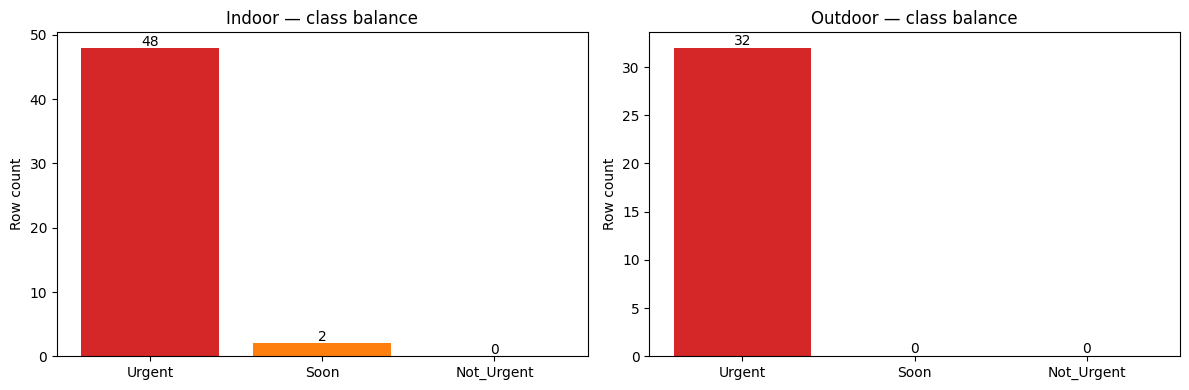

condition  urgency_class
indoor     Soon              2
           Urgent           48
outdoor    Urgent           32
dtype: int64


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
class_order = ["Urgent", "Soon", "Not_Urgent"]

for ax, condition in zip(axes, ["indoor", "outdoor"]):
    subset = df[df["condition"] == condition]
    counts = subset["urgency_class"].value_counts().reindex(class_order).fillna(0)
    ax.bar(counts.index, counts.values, color=["#d62728", "#ff7f0e", "#2ca02c"])
    ax.set_title(f"{condition.capitalize()} — class balance")
    ax.set_ylabel("Row count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.3, str(int(v)), ha="center")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_class_balance.png", dpi=120)
plt.show()

print(df.groupby(["condition", "urgency_class"]).size())

## Feature distributions — indoor vs outdoor

Do temperature/humidity/light actually look different between conditions, as the research design assumes they should?

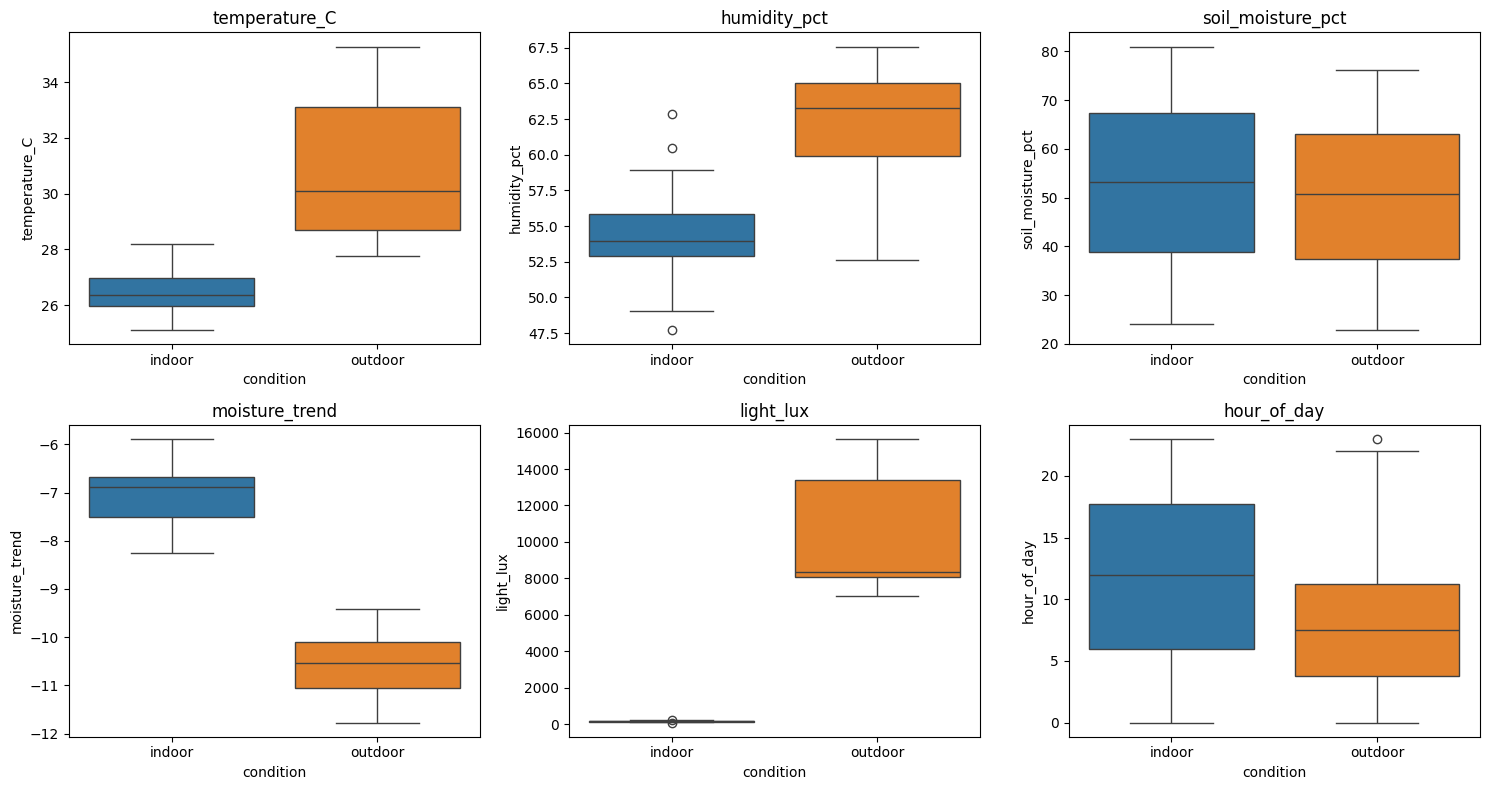

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, FEATURE_COLS):
    sns.boxplot(data=df, x="condition", y=col, ax=ax, hue="condition", legend=False)
    ax.set_title(col)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_feature_distributions.png", dpi=120)
plt.show()

## Feature correlation check

Is `moisture_trend` genuinely adding signal, or basically redundant with instantaneous moisture?

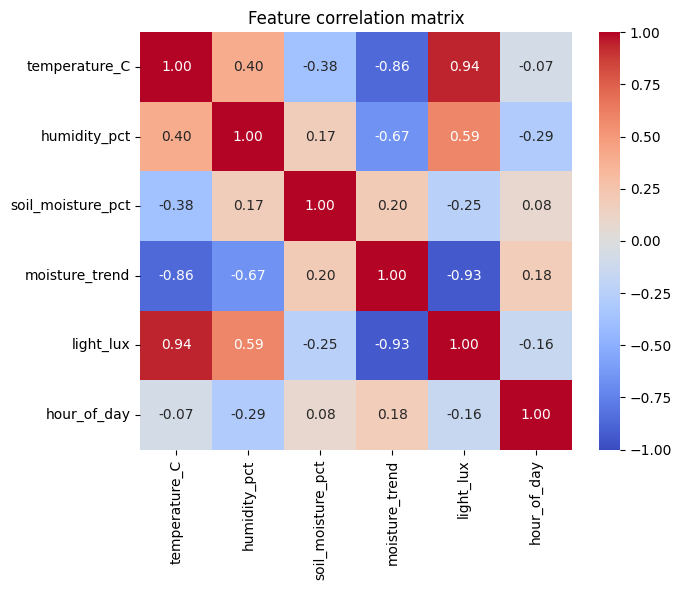

In [4]:
corr = df[FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_feature_correlation.png", dpi=120)
plt.show()

## Moisture trend vs instantaneous moisture, colored by urgency class

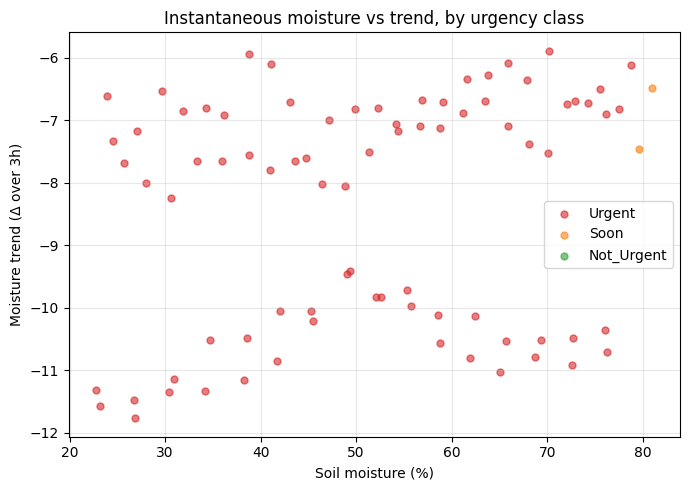

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = {"Urgent": "#d62728", "Soon": "#ff7f0e", "Not_Urgent": "#2ca02c"}

for cls, color in colors.items():
    subset = df[df["urgency_class"] == cls]
    ax.scatter(subset["soil_moisture_pct"], subset["moisture_trend"],
               label=cls, alpha=0.6, color=color, s=25)

ax.set_xlabel("Soil moisture (%)")
ax.set_ylabel("Moisture trend (Δ over 3h)")
ax.set_title("Instantaneous moisture vs trend, by urgency class")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_moisture_vs_trend.png", dpi=120)
plt.show()

**Next step:** `06_train_test_split_strategy.ipynb` — build the leave-one-cycle-out cross-validation splits.